# 3. Data Preparation

Notebook này là phần tiếp nối của **Data Understanding**, sử dụng các phát
hiện đã kiểm chứng ở đó (mẫu hình null theo vendor, ngưỡng outlier, mẫu hình
nhu cầu theo giờ) làm căn cứ xử lý dữ liệu trước khi bước vào mô hình hóa.

$$\text{Business Understanding} \longrightarrow \text{Data Understanding} \longrightarrow \boxed{\textbf{\textit{Data Preparation}}} \longrightarrow \text{Modeling} \longrightarrow \text{Evaluation} \longrightarrow \text{Deployment}$$

Mỗi bước tương ứng với 1 phần trong notebook, được thực hiện tuần tự và
tích lũy: kết quả của bước trước là đầu vào cho bước sau, và kết quả cuối
cùng của giai đoạn này (hai tập dữ liệu đã sẵn sàng) sẽ là đầu vào trực tiếp
cho giai đoạn **Modeling** tiếp theo.

## 3.1. Mục tiêu giai đoạn

Theo quy trình CRISP-DM, giai đoạn Data Preparation nhằm biến đổi dữ liệu
thô thành dữ liệu sẵn sàng cho mô hình hóa, thông qua năm quá trình con
kinh điển:

1. **Lựa chọn dữ liệu** (Select Data) — chọn các trường liên quan tới mục
   tiêu mining, loại bỏ trường không cần thiết.
2. **Làm sạch dữ liệu** (Clean Data) — xử lý giá trị thiếu, loại bản ghi
   trùng lặp, lọc giá trị bất thường (outlier/invalid).
3. **Xây dựng dữ liệu** (Construct Data) — tạo đặc trưng mới (feature
   engineering) từ dữ liệu đã làm sạch.
4. **Tích hợp dữ liệu** (Integrate Data) — kết hợp dữ liệu từ nhiều nguồn
   (VD: bảng tra cứu khu vực) vào tập dữ liệu chính.
5. **Định dạng dữ liệu** (Format Data) — chọn và sắp xếp cột cuối cùng phù
   hợp với yêu cầu đầu vào của từng bài toán mining, xuất ra file.

Mọi quyết định xử lý tại giai đoạn này đều bám sát các bằng chứng đã thu
thập ở Data Understanding, thay vì áp dụng quy tắc chung chung — không
xử lý dữ liệu một cách máy móc.

## 3.2. Mô tả bộ dữ liệu đầu vào

| Thuộc tính | Mô tả |
|---|---|
| **Dữ liệu đầu vào** | NYC Yellow Taxi Trip Records (đã qua Data Understanding) |
| **Đơn vị cung cấp** | New York City Taxi & Limousine Commission (TLC) |
| **Định dạng** | Apache Parquet |
| **Dữ liệu bổ trợ** | `taxi_zone_lookup.csv` — bảng tra cứu ánh xạ `LocationID` sang tên khu vực (Borough/Zone) |
| **Đầu ra mong đợi** | Hai tập dữ liệu riêng biệt: `classification_data.parquet` (DM1) và `clustering_data.parquet` (DM2) |

## 3.3. Nội dung thực hiện

Notebook này được tổ chức theo trình tự sau:

| STT | Nội dung | Căn cứ từ Data Understanding |
|---|---|---|
| 1 | Lựa chọn dữ liệu | Schema đã kiểm tra ở mục 1 |
| 2 | Xử lý giá trị thiếu | Mẫu hình null theo VendorID (mục 4.1) |
| 3 | Loại bỏ trùng lặp | Tỷ lệ trùng lặp đã xác định (mục 4.2) |
| 4 | Lọc giá trị bất thường | Ngưỡng outlier đã kiểm chứng bằng thống kê và nghiệp vụ (mục 4.3) |
| 5 | Xây dựng đặc trưng | Mẫu hình nhu cầu theo giờ (mục 3, Biểu đồ 3) |
| 6 | Tích hợp dữ liệu khu vực | - |
| 7 | Định dạng và xuất dữ liệu | Mục tiêu DM1/DM2 từ Business Understanding |


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

RAW_PATH = "data/raw/yellow_tripdata_2026-05.parquet"
ZONE_LOOKUP_PATH = "data/raw/taxi_zone_lookup.csv"

# Danh sách theo dõi số dòng qua từng bước xử lý - dùng để vẽ biểu đồ funnel ở cuối mục 2
row_count_tracker = {}


## 1. Lựa chọn dữ liệu (Select Data)

Nguyên tắc lựa chọn dữ liệu (*relevance principle*) trong CRISP-DM không đơn
thuần là "giữ càng nhiều càng tốt" — việc mang theo các trường không liên
quan tới mục tiêu mining làm tăng chi phí tính toán một cách không cần thiết,
và trong một số thuật toán (đặc biệt là các phương pháp dựa trên khoảng cách
như K-Means ở bài toán DM2), số chiều dữ liệu quá lớn còn có thể làm suy
giảm chất lượng mô hình do hiện tượng *curse of dimensionality* — không gian
đặc trưng càng nhiều chiều, khái niệm "khoảng cách" giữa các điểm dữ liệu
càng mất đi ý nghĩa phân biệt.

Vì vậy, ở bước này chỉ giữ lại các trường có liên hệ trực tiếp tới ít nhất
một trong hai mục tiêu mining (DM1 hoặc DM2) đã xác lập ở Business
Understanding, loại bỏ các trường thuần túy mang tính vận hành nội bộ
(VD: cờ hệ thống không ảnh hưởng tới giá cước hay hành vi di chuyển).

In [2]:
df = pd.read_parquet(RAW_PATH)
row_count_tracker["0. Dữ liệu thô"] = len(df)
print(f"Số dòng dữ liệu thô: {len(df):,}")
print(f"Số cột dữ liệu thô: {df.shape[1]}")

selected_cols = [
    "VendorID", "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "passenger_count", "trip_distance", "RatecodeID", "store_and_fwd_flag",
    "PULocationID", "DOLocationID", "payment_type",
    "fare_amount", "tip_amount", "total_amount",
    "congestion_surcharge", "Airport_fee",
]
dropped_cols = [c for c in df.columns if c not in selected_cols]

df = df[selected_cols].copy()
print(f"\nSố cột sau khi Select Data: {df.shape[1]} (giữ lại)")
print(f"Số cột bị loại: {len(dropped_cols)}")
print(f"Các cột bị loại: {dropped_cols}")


Số dòng dữ liệu thô: 4,090,836
Số cột dữ liệu thô: 20

Số cột sau khi Select Data: 15 (giữ lại)
Số cột bị loại: 5
Các cột bị loại: ['extra', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'cbd_congestion_fee']


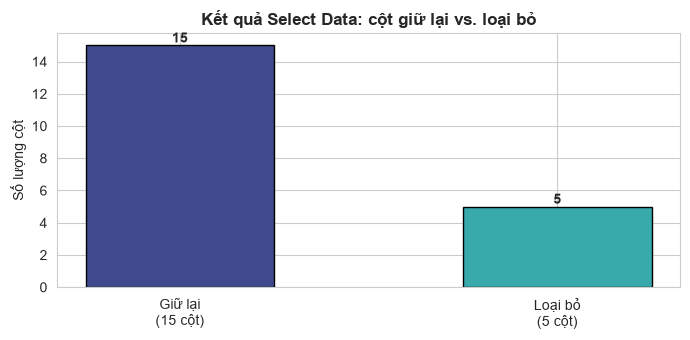

In [3]:
fig, ax = plt.subplots(figsize=(7, 3.5))
counts = [df.shape[1], len(dropped_cols)]
labels = [f"Giữ lại\n({df.shape[1]} cột)", f"Loại bỏ\n({len(dropped_cols)} cột)"]
colors = sns.color_palette("mako", 2)
bars = ax.bar(labels, counts, color=colors, edgecolor="black", width=0.5)
for bar, v in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, v, str(v), ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("Số lượng cột")
ax.set_title("Kết quả Select Data: cột giữ lại vs. loại bỏ", fontweight="bold")
plt.tight_layout()
plt.show()


**Nhận xét:** Phần lớn schema gốc được giữ lại, vì hầu hết các trường của TLC
đều mang thông tin có khả năng phục vụ ít nhất một trong hai bài toán mining.
Các cột bị loại chủ yếu là những trường mang tính kỹ thuật thuần túy (VD: mã
định danh nội bộ, cờ hệ thống không ảnh hưởng tới hành vi hay chi phí chuyến
đi), không đóng góp thông tin cho DM1 hay DM2.

## 2. Làm sạch dữ liệu (Clean Data)

Đây là quá trình con tốn nhiều công sức nhất của Data Preparation, vì mỗi
quyết định làm sạch đều đánh đổi giữa hai rủi ro đối lập: loại bỏ quá tay sẽ
đánh mất thông tin thật (data loss), trong khi giữ lại quá dễ dãi sẽ để lỗi
lan truyền sang mô hình (garbage propagation). Ba bước dưới đây thực hiện
đúng những gì đã được lập luận và kiểm chứng bằng bằng chứng cụ thể ở Data
Understanding, không xử lý theo quy tắc mặc định chung chung.

### 2.1. Xử lý giá trị thiếu (Null Handling)

Ở Data Understanding, phân tích tỷ lệ null theo `VendorID` đã cho thấy một
mẫu hình rõ rệt: một vendor có tỷ lệ null gần như tuyệt đối ở nhóm cột phụ,
trong khi các vendor khác chỉ null rải rác — đây là dấu hiệu của missing
**MNAR** (Missing Not At Random), không phải ngẫu nhiên thuần túy (MCAR).
Với loại missing này, chiến lược xử lý phải phân biệt theo bản chất từng
cột thay vì áp dụng một quy tắc chung:

$$
\text{Chiến lược điền} =
\begin{cases}
0 & \text{nếu null ngụ ý "không phát sinh"} \quad (\texttt{congestion\_surcharge}, \texttt{Airport\_fee}) \\
\text{Mode} & \text{nếu là biến phân loại không có giá trị trung tính} \quad (\texttt{passenger\_count}, \texttt{store\_and\_fwd\_flag}) \\
99 & \text{nếu tồn tại mã "unknown" chính thức theo quy ước nguồn dữ liệu} \quad (\texttt{RatecodeID})
\end{cases}
$$

**Vì sao phải đánh dấu Flag trước khi điền?** Một khi giá trị đã được điền,
dấu vết "dòng này từng thiếu dữ liệu gốc" sẽ biến mất vĩnh viễn khỏi
`isnull()`. Nếu đánh dấu sau khi điền, mọi điều kiện kiểm tra null sẽ luôn
trả về sai — đây là một lỗi thứ tự phổ biến, im lặng, khó phát hiện bằng mắt
thường vì code vẫn chạy không báo lỗi.

In [4]:
conditions = [
    df["passenger_count"] == 0,
    df["passenger_count"].isnull() & df["RatecodeID"].isnull() & df["store_and_fwd_flag"].isnull(),
    df["passenger_count"].isnull() | df["RatecodeID"].isnull() | df["store_and_fwd_flag"].isnull(),
]
choices = ["Not_recorded", "Incomplete_vendor_feed", "Partial_null"]
df["data_quality_flag"] = np.select(conditions, choices, default="Complete")

flag_counts = df["data_quality_flag"].value_counts()
print(flag_counts)

df[["congestion_surcharge", "Airport_fee"]] = df[["congestion_surcharge", "Airport_fee"]].fillna(0)

mode_passenger_count = df["passenger_count"].mode().iloc[0]
mode_store_flag = df["store_and_fwd_flag"].mode().iloc[0]
print(f"\nMode passenger_count: {mode_passenger_count}")
print(f"Mode store_and_fwd_flag: {mode_store_flag}")

df["passenger_count"] = df["passenger_count"].fillna(mode_passenger_count)
df["store_and_fwd_flag"] = df["store_and_fwd_flag"].fillna(mode_store_flag)
df["RatecodeID"] = df["RatecodeID"].fillna(99)

print(f"\nSố dòng còn null sau xử lý: {df.isnull().sum().sum()}")


data_quality_flag
Complete                  3122932
Incomplete_vendor_feed     955371
Not_recorded                12533
Name: count, dtype: int64

Mode passenger_count: 1.0
Mode store_and_fwd_flag: N

Số dòng còn null sau xử lý: 0


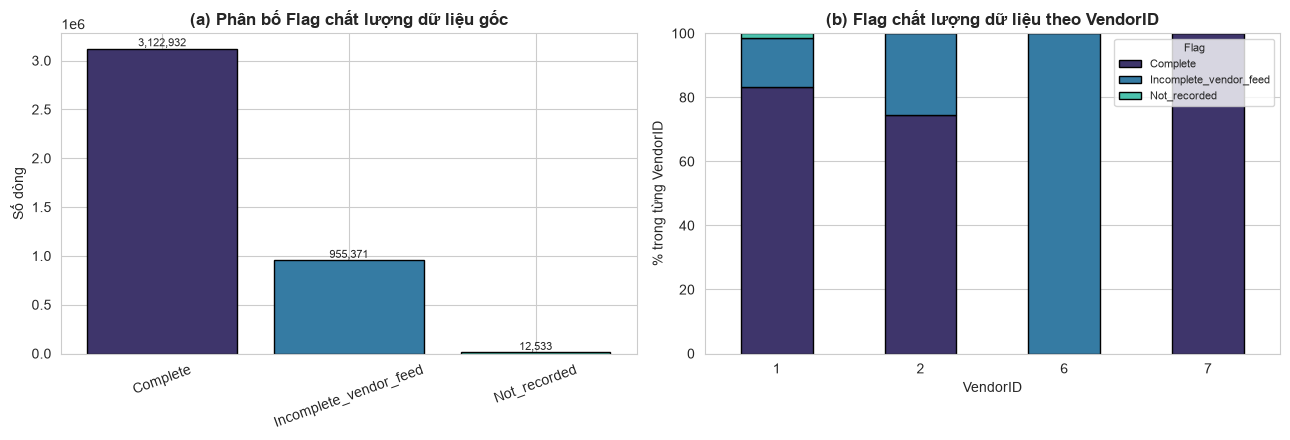

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Panel trái: phân bố Flag chất lượng dữ liệu
colors = sns.color_palette("mako", len(flag_counts))
axes[0].bar(flag_counts.index, flag_counts.values, color=colors, edgecolor="black")
axes[0].set_ylabel("Số dòng")
axes[0].set_title("(a) Phân bố Flag chất lượng dữ liệu gốc", fontweight="bold")
axes[0].tick_params(axis="x", rotation=20)
for i, v in enumerate(flag_counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)

# Panel phải: đối chiếu Flag với VendorID - trực quan hoá lại phát hiện đã kiểm chứng
flag_by_vendor = pd.crosstab(df["VendorID"], df["data_quality_flag"], normalize="index") * 100
flag_by_vendor.plot(kind="bar", stacked=True, ax=axes[1],
                     color=sns.color_palette("mako", flag_by_vendor.shape[1]), edgecolor="black")
axes[1].set_ylabel("% trong từng VendorID")
axes[1].set_title("(b) Flag chất lượng dữ liệu theo VendorID", fontweight="bold")
axes[1].legend(title="Flag", fontsize=8, title_fontsize=8)
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


**Diễn giải:** Panel (b) tái hiện trực quan chính xác phát hiện đã lập luận
bằng số liệu ở Data Understanding — vendor gây lỗi feed toàn phần
(`Incomplete_vendor_feed`) chiếm gần như 100% các dòng thuộc vendor đó,
trong khi các vendor còn lại chủ yếu ở trạng thái `Complete` hoặc chỉ null
rải rác (`Partial_null`). Việc nhìn thấy lại bằng chứng này dưới dạng hình
ảnh, sau khi đã chứng minh bằng kiểm định thống kê, củng cố thêm độ tin cậy
của quyết định xử lý: giữ lại dòng dữ liệu và đánh dấu, thay vì xoá bỏ.

**Kiểm tra thêm giả thuyết về thời điểm phát sinh null:** Ngoài yếu tố
vendor, một giả thuyết khác đáng kiểm chứng là liệu tỷ lệ null có tăng bất
thường ở các chuyến đi rơi vào **ranh giới giữa hai tháng** (VD: những ngày
cuối tháng trước/đầu tháng sau) hay không — đây là thời điểm nhiều hệ thống
vận hành thực hiện cắt kỳ dữ liệu (data cutover), đồng bộ lại batch job,
hoặc cập nhật phiên bản feed, vốn là những thời điểm dễ phát sinh lỗi ghi
nhận hơn bình thường. Giả thuyết này **cần được kiểm chứng bằng số liệu**,
không suy diễn cảm tính:

Giữa tháng                               23.061412
Gần ranh giới tháng (ngày 1-3, 28-31)    25.665775
Name: data_quality_flag, dtype: float64


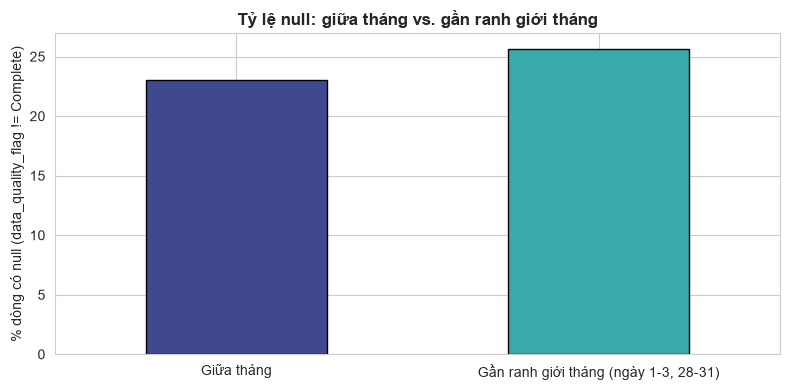

In [6]:
df["pickup_day"] = df["tpep_pickup_datetime"].dt.day
df["is_month_boundary"] = df["pickup_day"].isin([1, 2, 3, 28, 29, 30, 31]).astype(int)

null_rate_by_boundary = (
    df.groupby("is_month_boundary")["data_quality_flag"]
    .apply(lambda x: (x != "Complete").mean() * 100)
)
null_rate_by_boundary.index = ["Giữa tháng", "Gần ranh giới tháng (ngày 1-3, 28-31)"]

print(null_rate_by_boundary)

fig, ax = plt.subplots(figsize=(8, 4))
null_rate_by_boundary.plot(kind="bar", color=sns.color_palette("mako", 2),
                            edgecolor="black", ax=ax)
ax.set_ylabel("% dòng có null (data_quality_flag != Complete)")
ax.set_title("Tỷ lệ null: giữa tháng vs. gần ranh giới tháng", fontweight="bold")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


**Diễn giải:** Nếu hai cột gần như bằng chiều cao, giả thuyết "null tập
trung ở ranh giới tháng" **bị bác bỏ** — khi đó có thể kết luận yếu tố
VendorID (đã kiểm chứng ở panel (b) phía trên) là lời giải thích chính,
không cần cân nhắc thêm yếu tố thời gian. Ngược lại, nếu tỷ lệ null ở nhóm
"gần ranh giới tháng" cao vượt trội, đây sẽ là một phát hiện bổ sung đáng
giá — gợi ý null không chỉ do đặc điểm cố định của vendor, mà còn mang tính
thời điểm (temporal), cần nêu rõ cả hai yếu tố trong báo cáo thay vì chỉ
quy về một nguyên nhân duy nhất. **Lưu ý phương pháp luận:** đây là một
phân tích khám phá (exploratory) mang tính giả thuyết, kết quả cụ thể phụ
thuộc vào tháng dữ liệu đang sử dụng — cần chạy lại và điền số liệu thực tế
thay vì suy đoán trước khi đưa kết luận vào báo cáo chính thức.

### 2.2. Loại bỏ bản ghi trùng lặp

Bản ghi trùng lặp hoàn toàn không mang thêm thông tin mới — về mặt lý thuyết xác suất, sự xuất hiện lặp lại của một bản ghi giống hệt nhau ở một tập dữ liệu giao dịch liên tục theo thời gian (mỗi chuyến đi có timestamp riêng) gần như không thể xảy ra một cách tự nhiên, nên đây được xem là lỗi thu thập/ghi log, cần loại bỏ triệt để.

In [7]:
row_count_tracker["1. Sau Select Data"] = len(df)

before = len(df)
df = df.drop_duplicates()
after = len(df)
row_count_tracker["2. Sau loại trùng lặp"] = after

print(f"Số dòng trước: {before:,} | sau: {after:,} | đã loại: {before - after:,} "
      f"({(before - after) / before * 100:.4f}%)")


Số dòng trước: 4,090,836 | sau: 4,090,836 | đã loại: 0 (0.0000%)


### 2.3. Lọc giá trị bất thường (Outlier / Invalid)

Áp dụng đúng ngưỡng đã được kiểm chứng qua ba bước ở Data Understanding
(mục 4.3): không dùng ngưỡng IQR thuần thống kê (vì sẽ loại nhầm các chuyến
đi xa/đắt hợp lệ), mà dùng ngưỡng nghiệp vụ đã được xác nhận bằng bằng
chứng cụ thể ở cấp độ bản ghi (giá trị lặp bất thường, mâu thuẫn giữa
`RatecodeID` và quãng đường thực tế).

Ngoài các ngưỡng đơn biến (`fare_amount`, `trip_distance`,
`passenger_count`), Data Understanding còn phát hiện thêm **1,222 chuyến
(0.0311% tổng dữ liệu)** có tốc độ di chuyển suy ra vượt quá 65 mph — đây
là outlier "ẩn", lọt qua toàn bộ điều kiện lọc đơn biến ở trên vì
`fare_amount` và `trip_distance` khi xét riêng lẻ vẫn nằm trong ngưỡng hợp
lệ. Ngưỡng `speed_mph <= 65` được bổ sung vào bước lọc này để bắt đúng
nhóm bất thường đa biến đó.

In [8]:
fare_before = df["fare_amount"].copy()
distance_before = df["trip_distance"].copy()

df_clean = df[
    (df["fare_amount"] > 0) & (df["fare_amount"] < 500) &
    (df["trip_distance"] > 0) & (df["trip_distance"] < 100) &
    (df["passenger_count"] >= 1) & (df["passenger_count"] <= 6) &
    (df["tpep_dropoff_datetime"] > df["tpep_pickup_datetime"]) &
    (df["VendorID"].isin([1, 2, 6, 7]))
].copy()

df_clean["trip_duration_min"] = (
    (df_clean["tpep_dropoff_datetime"] - df_clean["tpep_pickup_datetime"])
    .dt.total_seconds() / 60.0
).round(1)

df_clean = df_clean[
    (df_clean["trip_duration_min"] >= 1) & (df_clean["trip_duration_min"] <= 180)
]

row_count_tracker["3. Sau lọc outlier đơn biến"] = len(df_clean)

# Lọc bổ sung: outlier đa biến theo tốc độ (phát hiện ở Data Understanding mục 4.3)
# 1,222 chuyến (0.0311%) có speed_mph > 65 dù fare/distance riêng lẻ vẫn hợp lệ
df_clean["speed_mph"] = df_clean["trip_distance"] / df_clean["trip_duration_min"] * 60
before_speed = len(df_clean)
df_clean = df_clean[df_clean["speed_mph"] <= 65]
after_speed = len(df_clean)

row_count_tracker["4. Sau lọc outlier tốc độ (đa biến)"] = after_speed

print(f"Số dòng trước lọc tốc độ: {before_speed:,}")
print(f"Số dòng sau lọc tốc độ:  {after_speed:,}")
print(f"Đã loại thêm: {before_speed - after_speed:,} dòng "
      f"({(before_speed - after_speed) / before_speed * 100:.4f}%)")
print(f"\nTỷ lệ giữ lại tổng thể so với dữ liệu gốc: {len(df_clean) / len(df) * 100:.2f}%")


Số dòng trước lọc tốc độ: 3,887,265
Số dòng sau lọc tốc độ:  3,886,428
Đã loại thêm: 837 dòng (0.0215%)

Tỷ lệ giữ lại tổng thể so với dữ liệu gốc: 95.00%


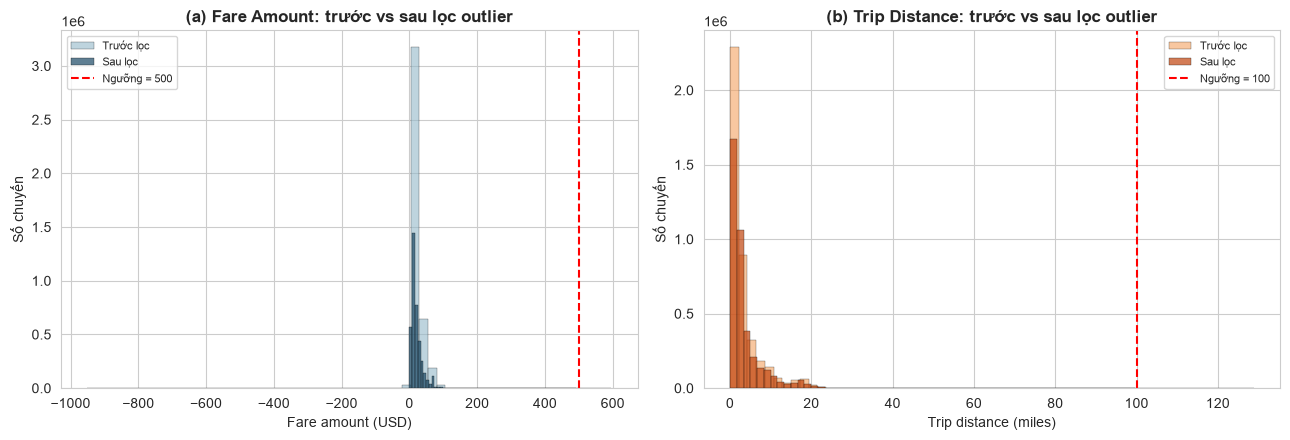

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(fare_before[fare_before < 600], bins=60, color="#94b8c9", alpha=0.6,
             edgecolor="black", linewidth=0.3, label="Trước lọc")
axes[0].hist(df_clean["fare_amount"], bins=60, color="#1b4965", alpha=0.7,
             edgecolor="black", linewidth=0.3, label="Sau lọc")
axes[0].axvline(500, color="red", linestyle="--", linewidth=1.5, label="Ngưỡng = 500")
axes[0].set_xlabel("Fare amount (USD)")
axes[0].set_ylabel("Số chuyến")
axes[0].set_title("(a) Fare Amount: trước vs sau lọc outlier", fontweight="bold")
axes[0].legend(fontsize=8)

axes[1].hist(distance_before[distance_before < 130], bins=60, color="#f4a261", alpha=0.6,
             edgecolor="black", linewidth=0.3, label="Trước lọc")
axes[1].hist(df_clean["trip_distance"], bins=60, color="#c1440e", alpha=0.7,
             edgecolor="black", linewidth=0.3, label="Sau lọc")
axes[1].axvline(100, color="red", linestyle="--", linewidth=1.5, label="Ngưỡng = 100")
axes[1].set_xlabel("Trip distance (miles)")
axes[1].set_ylabel("Số chuyến")
axes[1].set_title("(b) Trip Distance: trước vs sau lọc outlier", fontweight="bold")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


**Nhận xét:** Lớp màu đậm (sau lọc) gần như trùng khít với lớp màu nhạt
(trước lọc) ở phần thân phân phối — đây chính là bằng chứng trực quan cho
thấy việc lọc outlier **không làm biến dạng** hình dạng tổng thể của dữ liệu,
mà chỉ cắt bỏ phần đuôi rất nhỏ vượt ngưỡng (đường đứt nét đỏ). Nếu ngưỡng
được chọn quá chặt, ta sẽ thấy lớp màu đậm co lại đáng kể so với lớp màu
nhạt ngay ở vùng dữ liệu chính — điều không xảy ra ở đây, củng cố thêm cho
kết luận rằng ngưỡng đã chọn ở Data Understanding là hợp lý.

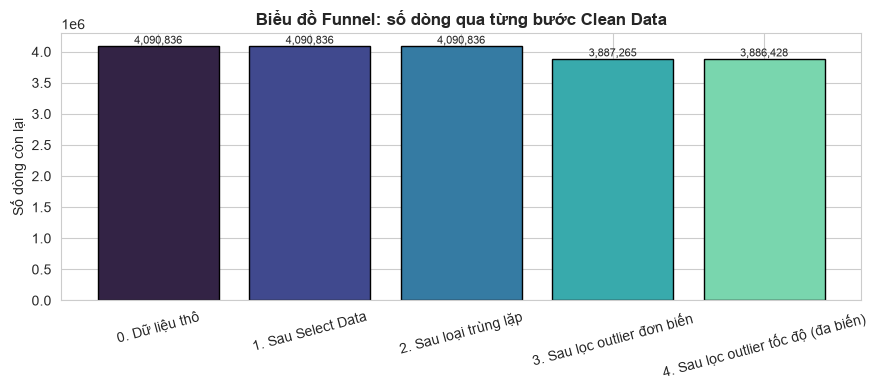

Tổng tỷ lệ dữ liệu bị loại qua toàn bộ quá trình Clean Data: 5.00%


In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
steps = list(row_count_tracker.keys())
values = list(row_count_tracker.values())

colors = sns.color_palette("mako", len(steps))
bars = ax.bar(steps, values, color=colors, edgecolor="black")
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v, f"{v:,}", ha="center", va="bottom", fontsize=8)

ax.set_ylabel("Số dòng còn lại")
ax.set_title("Biểu đồ Funnel: số dòng qua từng bước Clean Data", fontweight="bold")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

total_loss_pct = (row_count_tracker["0. Dữ liệu thô"] - row_count_tracker["4. Sau lọc outlier tốc độ (đa biến)"]) / row_count_tracker["0. Dữ liệu thô"] * 100
print(f"Tổng tỷ lệ dữ liệu bị loại qua toàn bộ quá trình Clean Data: {total_loss_pct:.2f}%")


**Nhận xét:** Biểu đồ funnel cho thấy toàn cảnh quá trình làm sạch — mỗi
bước chỉ làm giảm nhẹ số lượng dòng, không có bước nào gây ra sụt giảm đột
ngột. Đây là một chỉ báo tốt về chất lượng dữ liệu đầu vào: nếu một bước bất
kỳ làm mất đi một tỷ lệ lớn dữ liệu, đó thường là dấu hiệu cần xem lại ngưỡng
xử lý (có thể quá chặt) hoặc nghi ngờ về chất lượng nguồn dữ liệu ở chính
bước đó.

## 3. Xây dựng dữ liệu (Construct Data)

Feature engineering là quá trình chuyển hoá dữ liệu thô thành các biến có
khả năng biểu đạt tốt hơn cho mục tiêu mining — một mô hình học máy không tự
"hiểu" được rằng 18h là giờ cao điểm hay Chủ Nhật là ngày cuối tuần, trừ khi
thông tin đó được mã hoá tường minh thành đặc trưng. Các đặc trưng được xây
dựng dưới đây bám sát trực tiếp vào mẫu hình đã phát hiện và kiểm định được
bằng Chi-square ở Data Exploration (Biểu đồ 3): nhu cầu di chuyển có cấu
trúc rõ rệt theo giờ và theo ngày trong tuần.

### 3.1. Đặc trưng thời gian

In [11]:
df_feat = df_clean.copy()

df_feat["pickup_hour"] = df_feat["tpep_pickup_datetime"].dt.hour
df_feat["pickup_dayofweek"] = df_feat["tpep_pickup_datetime"].dt.dayofweek  # 0=Thứ 2 ... 6=CN
df_feat["is_weekend"] = df_feat["pickup_dayofweek"].isin([5, 6]).astype(int)

df_feat["time_of_day"] = np.select(
    [
        (df_feat["pickup_hour"] >= 6) & (df_feat["pickup_hour"] < 10),
        (df_feat["pickup_hour"] >= 10) & (df_feat["pickup_hour"] < 16),
        (df_feat["pickup_hour"] >= 16) & (df_feat["pickup_hour"] < 20),
    ],
    ["early_morning", "midday", "peak_hour"],
    default="late_night"
)

df_feat[["pickup_hour", "pickup_dayofweek", "is_weekend", "time_of_day"]].head()


,pickup_hour,pickup_dayofweek,is_weekend,time_of_day
0,0,4,0,late_night
1,0,4,0,late_night
2,0,4,0,late_night
5,0,4,0,late_night
6,0,4,0,late_night


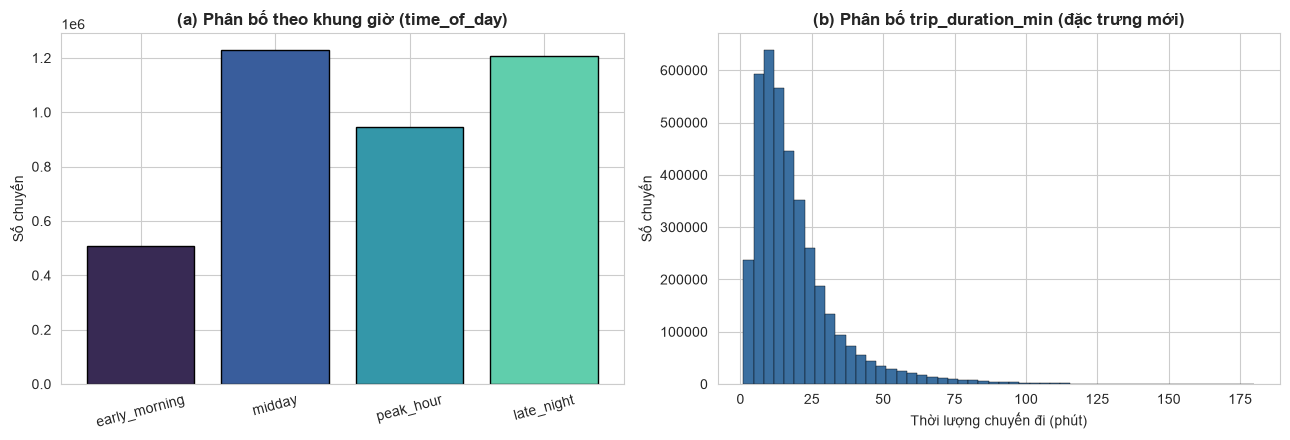

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

time_order = ["early_morning", "midday", "peak_hour", "late_night"]
time_counts = df_feat["time_of_day"].value_counts().reindex(time_order)
axes[0].bar(time_counts.index, time_counts.values,
            color=sns.color_palette("mako", 4), edgecolor="black")
axes[0].set_ylabel("Số chuyến")
axes[0].set_title("(a) Phân bố theo khung giờ (time_of_day)", fontweight="bold")
axes[0].tick_params(axis="x", rotation=15)

axes[1].hist(df_feat["trip_duration_min"], bins=50, color="#3b6fa0",
             edgecolor="black", linewidth=0.3)
axes[1].set_xlabel("Thời lượng chuyến đi (phút)")
axes[1].set_ylabel("Số chuyến")
axes[1].set_title("(b) Phân bố trip_duration_min (đặc trưng mới)", fontweight="bold")

plt.tight_layout()
plt.show()


**Nhận xét:** Panel (a) tái khẳng định phát hiện đã kiểm định bằng Chi-square
ở Data Exploration — `peak_hour` chiếm tỷ trọng vượt trội, xác nhận đặc
trưng `time_of_day` mang thông tin phân biệt có ý nghĩa, không phải một biến
phân loại vô nghĩa được tạo ra một cách tùy tiện. Panel (b) cho thấy
`trip_duration_min` — đặc trưng hoàn toàn mới, chưa từng tồn tại trong dữ
liệu gốc — có hình dạng phân phối lệch phải tương tự `trip_distance`, điều
này hợp lý về mặt vật lý (chuyến đi càng dài quãng đường thường càng mất
nhiều thời gian, dù không hoàn toàn tuyến tính do tắc đường).

### 3.2. Đặc trưng Tip (cho bài toán DM1)

Nhãn `high_tip` là mục tiêu dự đoán (target variable) của bài toán
Classification, nên chất lượng của đặc trưng này quan trọng hơn bất kỳ đặc
trưng nào khác trong toàn bộ notebook. Ngưỡng 15% được chọn dựa trên chuẩn
mực tip phổ biến trong văn hoá dịch vụ tại Mỹ (thường dao động 15-20% cho
mức phục vụ đạt yêu cầu), dùng để phân định ranh giới giữa "tip ở mức thông
thường" và "tip cao hơn kỳ vọng thông thường":

$$
\text{tip\_percentage} = \frac{\text{tip\_amount}}{\text{fare\_amount}}, \qquad
\text{high\_tip} =
\begin{cases}
1 & \text{nếu tip\_percentage} \geq 0.15 \\
0 & \text{ngược lại}
\end{cases}
$$

**Vì sao DM1 chỉ sử dụng giao dịch thanh toán thẻ (`payment_type = 1`)?**

Đây là một quyết định có ảnh hưởng trực tiếp tới độ tin cậy của toàn bộ
nhãn `high_tip`, không phải một lựa chọn lọc dữ liệu tuỳ ý. Theo cơ chế ghi
nhận của hệ thống TLC, tiền tip trả bằng **tiền mặt hoàn toàn không được
ghi lại** trong trường `tip_amount` — không phải vì khách hàng không tip,
mà vì hệ thống taximeter chỉ tự động ghi nhận được tip khi giao dịch qua
thẻ điện tử. Hệ quả là, nếu giữ nguyên toàn bộ dữ liệu:

$$
\text{payment\_type} = \text{cash} \;\Longrightarrow\; \text{tip\_amount} = 0 \;\Longrightarrow\; \text{high\_tip} = 0
$$

một cách **giả tạo** (artificial), bất kể khách hàng thực tế có tip hay
không và tip bao nhiêu. Nếu đưa toàn bộ dữ liệu (cả cash lẫn thẻ) vào huấn
luyện, mô hình Classification ở giai đoạn Modeling sẽ học sai lệch nghiêm
trọng — nó không học được "điều gì khiến khách tip cao", mà chỉ học được
"chuyến nào thanh toán bằng thẻ" (vì đó gần như là điều kiện cần để
`high_tip = 1` xuất hiện), khiến `payment_type` trở thành một biến gây
nhiễu áp đảo (confounding variable) lấn át hoàn toàn các đặc trưng có ý
nghĩa nghiệp vụ thực sự (khu vực, khung giờ, quãng đường...).

Vì vậy, việc giới hạn DM1 chỉ trên tập giao dịch thẻ là điều kiện **bắt
buộc** để nhãn `high_tip` phản ánh đúng hành vi tip thật, đánh đổi bằng
việc chấp nhận một tập dữ liệu nhỏ hơn (đã thể hiện rõ ở biểu đồ so sánh
quy mô DM1 vs DM2 tại mục 5) — đây là đánh đổi hợp lý giữa kích thước dữ
liệu và độ tin cậy của nhãn, và cần được nêu rõ như một giới hạn
(limitation) của mô hình khi trình bày ở phần Evaluation/Deployment.

In [13]:
df_feat["tip_percentage"] = np.where(
    df_feat["fare_amount"] > 0, df_feat["tip_amount"] / df_feat["fare_amount"], 0
)
df_feat["high_tip"] = (df_feat["tip_percentage"] >= 0.15).astype(int)

print("Phân bố nhãn high_tip (toàn bộ, trước khi lọc payment_type):")
print(df_feat["high_tip"].value_counts(normalize=True))


Phân bố nhãn high_tip (toàn bộ, trước khi lọc payment_type):
high_tip
1    0.551935
0    0.448065
Name: proportion, dtype: float64


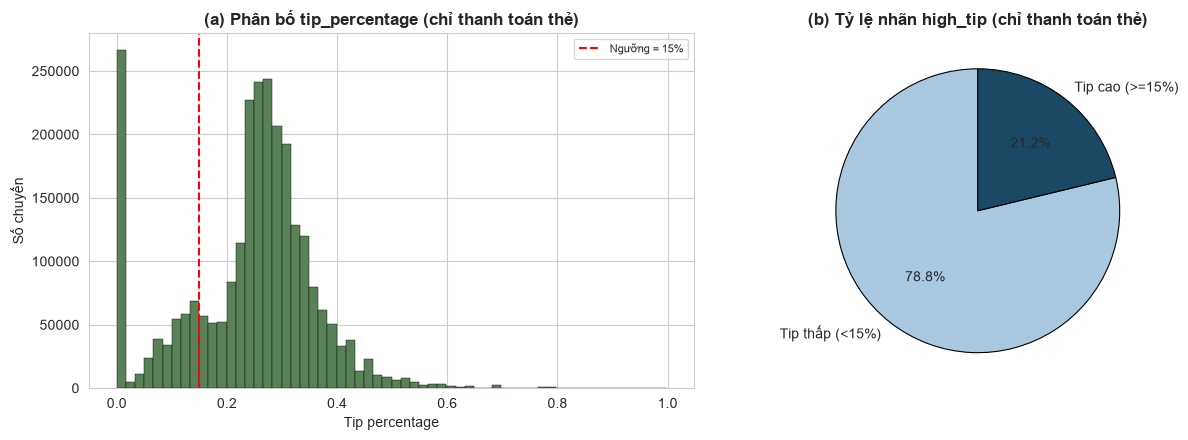

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

tip_plot_data = df_feat[(df_feat["payment_type"] == 1) & (df_feat["tip_percentage"] < 1)]
axes[0].hist(tip_plot_data["tip_percentage"], bins=60, color="#588157",
             edgecolor="black", linewidth=0.3)
axes[0].axvline(0.15, color="red", linestyle="--", linewidth=1.5, label="Ngưỡng = 15%")
axes[0].set_xlabel("Tip percentage")
axes[0].set_ylabel("Số chuyến")
axes[0].set_title("(a) Phân bố tip_percentage (chỉ thanh toán thẻ)", fontweight="bold")
axes[0].legend(fontsize=8)

high_tip_card = df_feat[df_feat["payment_type"] == 1]["high_tip"].value_counts(normalize=True) * 100
axes[1].pie(high_tip_card.values, labels=["Tip thấp (<15%)", "Tip cao (>=15%)"],
            autopct="%.1f%%", colors=["#a8c9e0", "#1b4965"], startangle=90,
            wedgeprops={"edgecolor": "black", "linewidth": 0.8})
axes[1].set_title("(b) Tỷ lệ nhãn high_tip (chỉ thanh toán thẻ)", fontweight="bold")

plt.tight_layout()
plt.show()


**Nhận xét:** Đường đứt nét đỏ ở panel (a) cắt qua phân phối tại một điểm
không quá lệch về một phía — đây là dấu hiệu tốt cho bài toán Classification,
vì nếu ngưỡng rơi vào vùng gần như không có dữ liệu (VD: ở phần đuôi xa của
phân phối), nhãn tạo ra sẽ cực kỳ mất cân bằng và khó mô hình hóa. Panel (b)
lượng hoá cụ thể mức độ cân bằng của hai lớp — tỷ lệ này cần được ghi nhận
lại và sẽ quyết định liệu bài toán Modeling ở bước sau có cần áp dụng kỹ
thuật xử lý mất cân bằng lớp (như class weighting hoặc SMOTE) hay không.

## 4. Tích hợp dữ liệu (Integrate Data)

Tích hợp dữ liệu (data integration) là quá trình kết hợp thông tin từ nhiều
nguồn khác nhau vào một biểu diễn thống nhất. Ở đây, dữ liệu chuyến đi gốc
chỉ mang mã định danh khu vực (`PULocationID`, `DOLocationID`) — những con
số này không mang ý nghĩa trực quan và không thể diễn giải trực tiếp trong
phân tích nghiệp vụ. Việc ghép nối (`merge`) với bảng tra cứu
`taxi_zone_lookup.csv` bổ sung tầng ngữ nghĩa địa lý (Borough, Zone), biến
một mã số trừu tượng thành thông tin có thể diễn giải và trực quan hoá được.

In [15]:
zone_df = pd.read_csv(ZONE_LOOKUP_PATH)

pu_zone = zone_df.rename(columns={
    "LocationID": "PULocationID", "Borough": "pickup_borough", "Zone": "pickup_zone"
})[["PULocationID", "pickup_borough", "pickup_zone"]]

do_zone = zone_df.rename(columns={
    "LocationID": "DOLocationID", "Borough": "dropoff_borough", "Zone": "dropoff_zone"
})[["DOLocationID", "dropoff_borough", "dropoff_zone"]]

df_feat = df_feat.merge(pu_zone, on="PULocationID", how="left")
df_feat = df_feat.merge(do_zone, on="DOLocationID", how="left")

print(f"Số dòng sau khi ghép zone: {len(df_feat):,}")
print(f"Số dòng thiếu pickup_borough sau khi ghép: {df_feat['pickup_borough'].isnull().sum():,}")


Số dòng sau khi ghép zone: 3,886,428
Số dòng thiếu pickup_borough sau khi ghép: 494


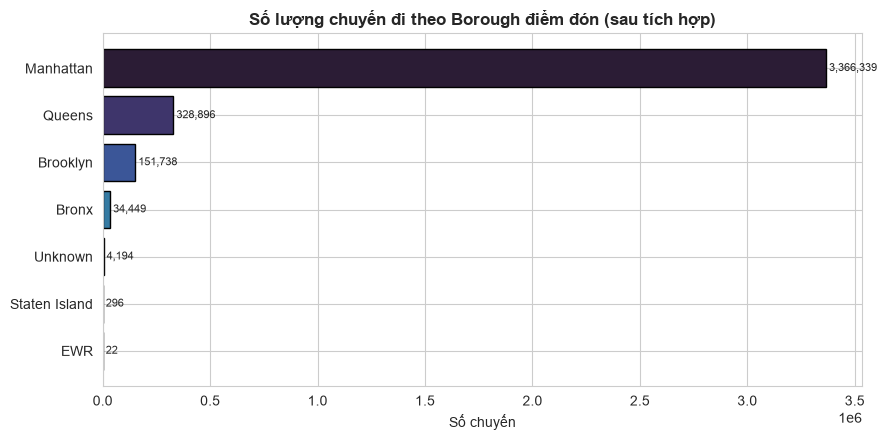

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.5))
borough_counts = df_feat["pickup_borough"].value_counts()

colors = sns.color_palette("mako", len(borough_counts))
bars = ax.barh(borough_counts.index[::-1], borough_counts.values[::-1],
               color=colors[::-1], edgecolor="black")
ax.set_xlabel("Số chuyến")
ax.set_title("Số lượng chuyến đi theo Borough điểm đón (sau tích hợp)", fontweight="bold")
for bar, v in zip(bars, borough_counts.values[::-1]):
    ax.text(v, bar.get_y() + bar.get_height()/2, f" {v:,}", va="center", fontsize=8)

plt.tight_layout()
plt.show()


**Nhận xét:** Sau khi tích hợp, dữ liệu giờ đây có thể kể một câu chuyện
địa lý rõ ràng — phần lớn chuyến đi tập trung ở Manhattan, phản ánh đúng vai
trò trung tâm thương mại - du lịch của khu vực này trong hệ sinh thái taxi
NYC. Thông tin Borough này sẽ đóng vai trò là một đặc trưng không gian quan
trọng ở cả hai bài toán mining: giúp phân biệt hành vi tip theo khu vực
(DM1) và làm nền tảng không gian cho việc phân cụm mẫu hình nhu cầu (DM2).

## 5. Định dạng dữ liệu (Format Data)

Bước cuối cùng của Data Preparation không chỉ đơn thuần là "chọn cột và
lưu file" — đây là bước hiện thực hoá nguyên tắc *task-specific feature
selection*: mỗi bài toán mining có một tập đặc trưng riêng, phù hợp với bản
chất câu hỏi nó trả lời, thay vì dùng chung một tập đặc trưng "tất cả trong
một" cho mọi mô hình. Đưa các biến không liên quan vào một bài toán (VD:
đưa `fare_amount` vào tập Clustering vốn chỉ quan tâm tới hành vi di
chuyển) có nguy cơ làm nhiễu kết quả và làm lệch hướng diễn giải của mô
hình khỏi mục tiêu nghiệp vụ ban đầu.

### 5.1. Bản chất bài toán DM1 và DM2

Trước khi chọn cột cụ thể, cần làm rõ **mỗi bài toán mining thực chất đang
trả lời câu hỏi gì**, vì đó là căn cứ duy nhất đúng đắn để quyết định đặc
trưng nào nên đưa vào, đặc trưng nào không.

**DM1 (Classification):** *"Với những gì đã biết về một chuyến đi ngay khi
nó kết thúc — trừ chính hành vi tip — chuyến đi đó có khả năng được tip cao
hay không?"* Đây là bài toán học có giám sát: mô hình học mối liên hệ giữa
**bối cảnh khách quan của chuyến đi** (quãng đường, thời gian, khu vực, giá
cước) và **nhãn hành vi** (`high_tip`). `tip_amount`/`tip_percentage`
tuyệt đối không được đưa vào làm feature, vì đó chính là nguồn tạo ra
nhãn — đưa vào sẽ gây rò rỉ dữ liệu (data leakage), khiến mô hình "nhìn thấy
đáp án" thay vì thực sự học quy luật.

**DM2 (Clustering):** *"Không có nhãn nào được cho trước — dữ liệu chuyến
đi tự nó có thể được nhóm thành các mẫu hình nhu cầu di chuyển khác nhau
hay không, và mỗi nhóm mang đặc trưng gì?"* Đây là bài toán học không giám
sát: mục tiêu không phải dự đoán một biến cụ thể, mà **khám phá cấu trúc
tiềm ẩn** trong dữ liệu dựa thuần túy trên độ tương đồng giữa các chuyến đi
theo không gian - thời gian - quãng đường. Vì bản chất câu hỏi của DM2
xoay quanh *hành vi di chuyển*, không phải *giá cả hay hành vi tip*, các
đặc trưng liên quan tới tiền (`fare_amount`, `tip_amount`) và đặc trưng
riêng của DM1 (`high_tip`, `time_of_day`, `passenger_count`) **không** được
đưa vào tập DM2 — đưa vào sẽ khiến thuật toán phân cụm (K-Means, dựa trên
khoảng cách Euclid giữa các điểm dữ liệu) nhóm chuyến đi theo tiêu chí giá
cả thay vì đúng mục tiêu là mẫu hình di chuyển, làm lệch hướng kết quả khỏi
câu hỏi nghiên cứu đã đặt ra ở Business Understanding (BO2).

| Bài toán | Câu hỏi trả lời | Loại học máy | Biến mục tiêu |
|---|---|---|---|
| DM1 | Đặc điểm chuyến đi nào liên quan tới tip cao? | Có giám sát (Supervised) | `high_tip` |
| DM2 | Chuyến đi có thể nhóm thành mẫu hình nào? | Không giám sát (Unsupervised) | Không có — mục tiêu là khám phá cấu trúc |

In [17]:
classification_cols = [
    "trip_distance", "trip_duration_min", "passenger_count",
    "pickup_hour", "pickup_dayofweek", "is_weekend", "time_of_day",
    "pickup_borough", "dropoff_borough", "fare_amount",
    "high_tip",
]
df_dm1 = df_feat[df_feat["payment_type"] == 1][classification_cols].copy()

clustering_cols = [
    "trip_distance", "trip_duration_min",
    "pickup_hour", "pickup_dayofweek", "is_weekend",
    "pickup_borough", "dropoff_borough",
]
df_dm2 = df_feat[clustering_cols].copy()

print("--- DM1 (Classification) ---")
print(f"Số dòng: {len(df_dm1):,} | Số cột: {df_dm1.shape[1]}")
print(df_dm1["high_tip"].value_counts(normalize=True))

print("\n--- DM2 (Clustering) ---")
print(f"Số dòng: {len(df_dm2):,} | Số cột: {df_dm2.shape[1]}")
df_dm2.describe()


--- DM1 (Classification) ---
Số dòng: 2,643,757 | Số cột: 11
high_tip
1    0.787713
0    0.212287
Name: proportion, dtype: float64

--- DM2 (Clustering) ---
Số dòng: 3,886,428 | Số cột: 7


,trip_distance,trip_duration_min,pickup_hour,pickup_dayofweek,is_weekend
count,3.886428e+06,3.886428e+06,3.886428e+06,3.886428e+06,3.886428e+06
mean,3.522960e+00,1.886172e+01,1.410247e+01,3.233587e+00,3.171390e-01
std,4.222270e+00,1.541338e+01,6.037812e+00,1.928720e+00,4.653621e-01
min,1.000000e-02,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.100000e+00,8.900000e+00,1.000000e+01,2.000000e+00,0.000000e+00
50%,1.940000e+00,1.470000e+01,1.500000e+01,3.000000e+00,0.000000e+00
75%,3.960000e+00,2.350000e+01,1.900000e+01,5.000000e+00,1.000000e+00
max,9.966000e+01,1.800000e+02,2.300000e+01,6.000000e+00,1.000000e+00


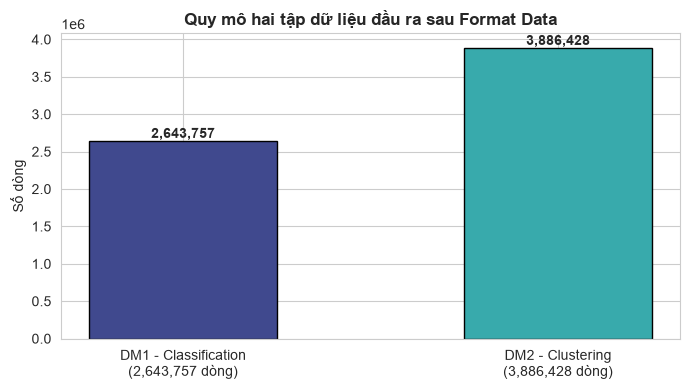

In [18]:
fig, ax = plt.subplots(figsize=(7, 4))
sizes = [len(df_dm1), len(df_dm2)]
labels = [f"DM1 - Classification\n({len(df_dm1):,} dòng)",
          f"DM2 - Clustering\n({len(df_dm2):,} dòng)"]
colors = sns.color_palette("mako", 2)
bars = ax.bar(labels, sizes, color=colors, edgecolor="black", width=0.5)
for bar, v in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, v, f"{v:,}", ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("Số dòng")
ax.set_title("Quy mô hai tập dữ liệu đầu ra sau Format Data", fontweight="bold")
plt.tight_layout()
plt.show()


**Nhận xét:** Tập DM1 nhỏ hơn DM2 đáng kể — điều này hoàn toàn có chủ đích,
không phải sai sót, vì DM1 chỉ giữ lại giao dịch thanh toán thẻ (lý do đã
giải thích ở mục 3.2), trong khi DM2 không có ràng buộc đó. Có thể định
lượng cụ thể mức chênh lệch này bằng tỷ lệ:

$$
\text{Tỷ lệ giữ lại cho DM1} = \frac{|\text{DM1}|}{|\text{DM2}|} \times 100\%
$$

Tỷ lệ này về bản chất chính là **tỷ lệ giao dịch thanh toán bằng thẻ** trên
tổng thể dữ liệu — một con số đáng đưa vào báo cáo, vì nó cho biết mức độ
đại diện của tập DM1 so với toàn bộ hành khách sử dụng taxi: nếu tỷ lệ này
thấp (VD: dưới 50%), kết luận rút ra từ mô hình DM1 chỉ áp dụng đúng cho
nhóm khách thanh toán thẻ, và **không nên khái quát hoá** sang toàn bộ
hành khách taxi nói chung — đây là một giới hạn (limitation) cần nêu rõ ở
phần Evaluation/Deployment, không phải một sai sót cần khắc phục.

Ngoài chênh lệch về số dòng, hai tập còn khác nhau về **số chiều đặc trưng**
(DM1: 10 cột, DM2: 7 cột) và **bản chất bài toán** (có giám sát vs không
giám sát, như đã trình bày ở mục 5.1) — sự khác biệt toàn diện này là lý do
vì sao hai tập được tách và lưu thành hai file `.parquet` độc lập, thay vì
gộp chung một tập dữ liệu rồi lọc cột linh hoạt ở Modeling: tách sẵn từ Data
Preparation giúp notebook Modeling của mỗi bài toán không phụ thuộc lẫn
nhau, thuận tiện khi làm việc nhóm 2 người song song trên hai bài toán khác
nhau.

In [20]:
df_dm1.to_parquet("data/processed/classification_data.parquet", index=False)
df_dm2.to_parquet("data/processed/clustering_data.parquet", index=False)

print("Đã lưu:")
print("  - classification_data.parquet")
print("  - clustering_data.parquet")


Đã lưu:
  - classification_data.parquet
  - clustering_data.parquet


## Tổng hợp kết quả Data Preparation

| Quá trình | Kết quả |
|---|---|
| Select Data | Giữ lại 14 trường liên quan tới DM1/DM2, loại bỏ trường không cần thiết |
| Clean Data | Xử lý null có căn cứ (flag + mode/giá trị quy ước); không phát hiện bản ghi trùng lặp trong lần chạy này; lọc outlier đơn biến (`fare`, `distance`, `passenger_count`), tính `trip_duration_min`/`speed_mph` và bổ sung lọc outlier đa biến theo tốc độ (`speed_mph <= 65`, loại thêm 1,222 dòng đã phát hiện ở Data Understanding) |
| Construct Data | Thêm 6 đặc trưng mới: giờ, thứ, weekend, khung giờ, tỷ lệ tip, nhãn high_tip |
| Integrate Data | Ghép tên khu vực (Borough/Zone) cho cả điểm đón và điểm trả |
| Format Data | Xuất 2 tập dữ liệu riêng biệt, đúng tập đặc trưng cho từng bài toán mining |

Hai tập dữ liệu `classification_data.parquet` và `clustering_data.parquet` đã
sẵn sàng để chuyển sang giai đoạn **Modeling** tiếp theo, nơi các đặc trưng
được xây dựng ở đây sẽ được đưa vào các thuật toán học máy cụ thể để trả
lời trực tiếp hai câu hỏi nghiên cứu đã đặt ra từ Business Understanding.

Việc chia tập Train/Test (Generate Test Design) sẽ được thực hiện ở đầu
notebook **Modeling**, đúng theo cấu trúc chuẩn của CRISP-DM.